# PoG Coordinate Origin Investigation

**Question:** Is `(0,0)` at the camera or at the screen center?

**Answer:** At the camera. The GazeCapture repo [documents this explicitly](https://github.com/CSAILVision/GazeCapture):
> `XCam, YCam`: Position of the dot measured in **centimeters relative to the camera center**. `YCam` values will be **negative for portrait mode** since the screen is below the camera.

This notebook confirms that empirically and quantifies the impact on our labels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
# !!! UPDATE THESE PATHS
LABELS_PATH = './gaze_labels.csv'
DEVICE_CSV_PATH = './apple_device_data.csv'

df = pd.read_csv(LABELS_PATH)
print(f"Loaded {len(df):,} rows")
print(f"Columns: {list(df.columns)}")
df[['pog_x', 'pog_y']].describe()

Loaded 849,131 rows
Columns: ['subject_id', 'frame_idx', 'pog_x', 'pog_y', 'label']


,pog_x,pog_y
count,849131.000000,849131.000000
mean,0.111662,-2.025536
std,5.868216,4.567280
min,-20.254602,-20.254602
25%,-3.643025,-4.291314
50%,0.366487,-1.359271
75%,3.642025,0.746985
max,20.254602,20.254602


---
## 1. Where is the density?

If `(0,0)` is at the camera, the densest region should sit below zero on Y (screen is below camera in portrait mode).

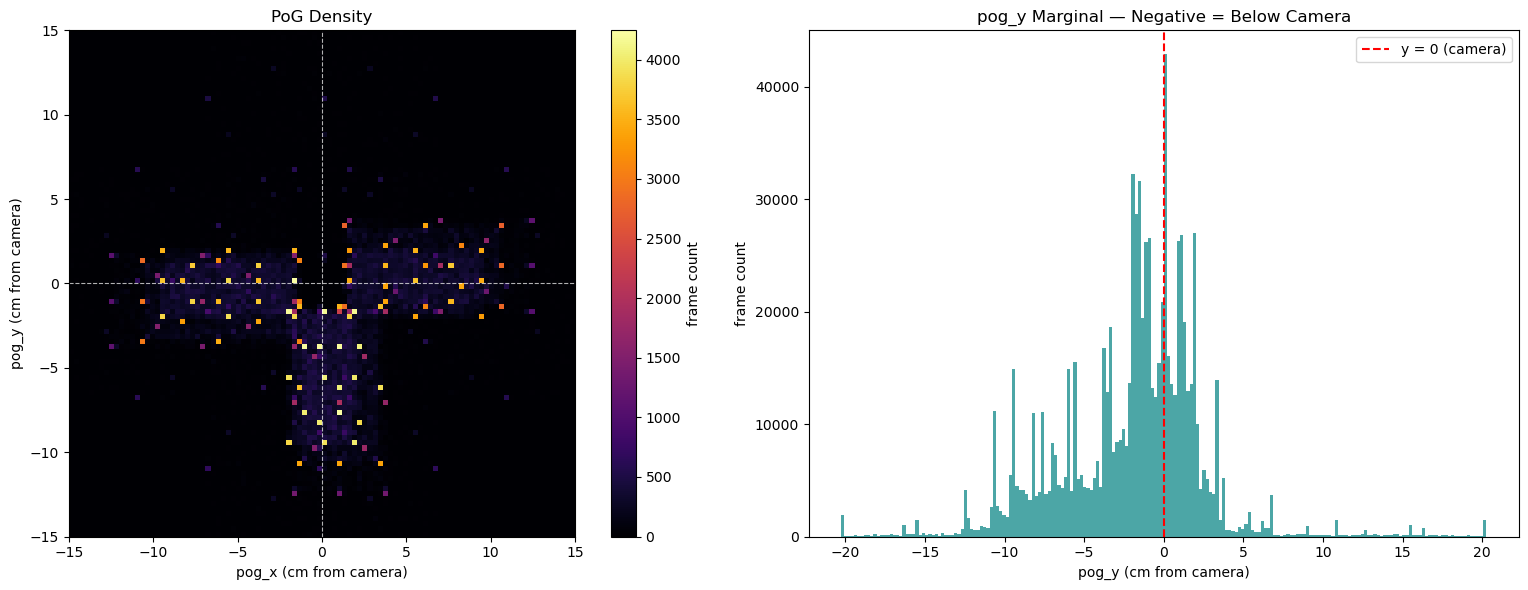


Median pog_x: 0.37 cm
Median pog_y: -1.36 cm


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

h = axes[0].hist2d(
    df['pog_x'], df['pog_y'],
    bins=100, range=[[-15, 15], [-15, 15]], cmap='inferno'
)
axes[0].axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.7)
axes[0].axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.7)
axes[0].set_xlabel('pog_x (cm from camera)')
axes[0].set_ylabel('pog_y (cm from camera)')
axes[0].set_title('PoG Density')
axes[0].set_aspect('equal')
plt.colorbar(h[3], ax=axes[0], label='frame count')

axes[1].hist(df['pog_y'], bins=200, color='teal', alpha=0.7, edgecolor='none')
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='y = 0 (camera)')
axes[1].set_xlabel('pog_y (cm from camera)')
axes[1].set_ylabel('frame count')
axes[1].set_title('pog_y Marginal — Negative = Below Camera')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMedian pog_x: {df['pog_x'].median():.2f} cm")
print(f"Median pog_y: {df['pog_y'].median():.2f} cm")

---
## 2. Current 5-class labels with camera-origin boundaries

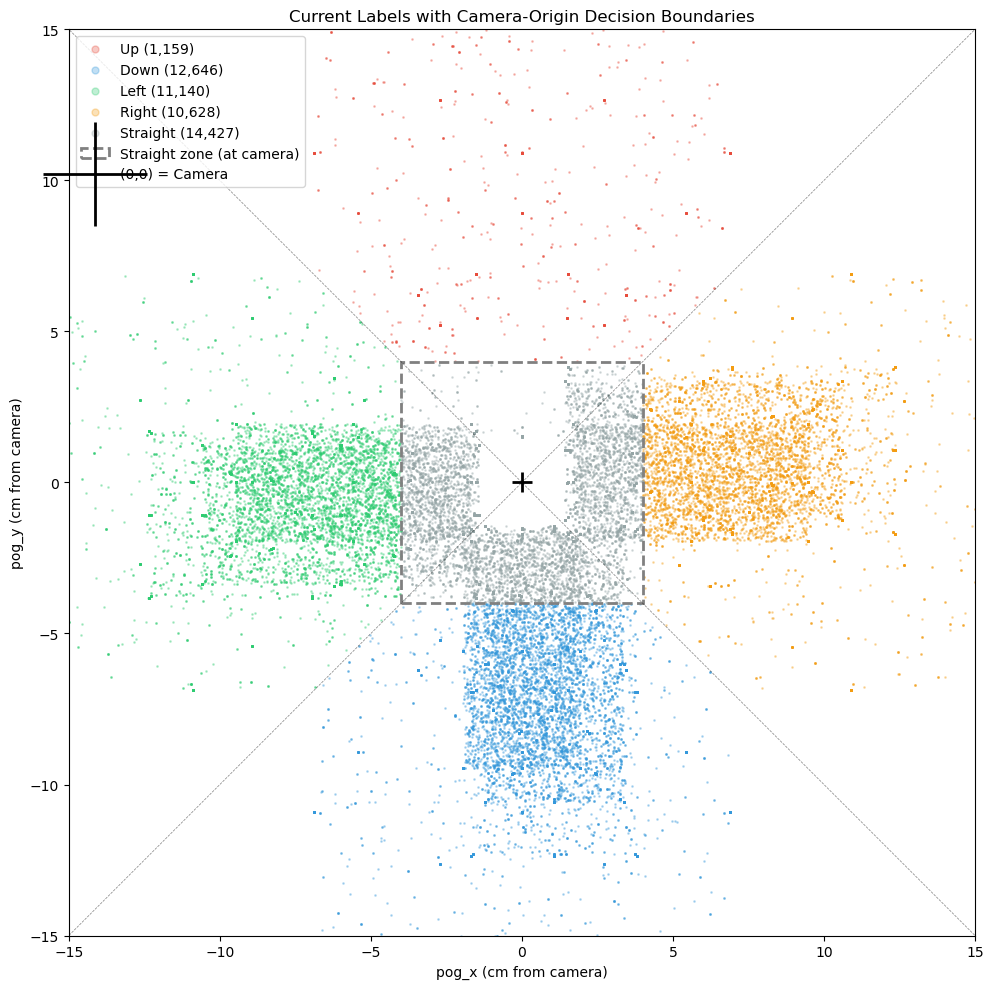

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

sample = df.sample(n=min(50_000, len(df)), random_state=42)

label_colors = {
    'Up': '#e74c3c', 'Down': '#3498db',
    'Left': '#2ecc71', 'Right': '#f39c12', 'Straight': '#95a5a6'
}

for label, color in label_colors.items():
    mask = sample['label'] == label
    if mask.sum() > 0:
        ax.scatter(sample.loc[mask, 'pog_x'], sample.loc[mask, 'pog_y'],
                   c=color, s=1, alpha=0.3, label=f"{label} ({mask.sum():,})")

rect = Rectangle((-4, -4), 8, 8, linewidth=2, edgecolor='gray',
                 facecolor='none', linestyle='--', label='Straight zone (at camera)')
ax.add_patch(rect)

lim = 20
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.5, alpha=0.5)
ax.plot([-lim, lim], [lim, -lim], 'k--', linewidth=0.5, alpha=0.5)
ax.plot(0, 0, 'k+', markersize=15, markeredgewidth=2, label='(0,0) = Camera')

ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_xlabel('pog_x (cm from camera)')
ax.set_ylabel('pog_y (cm from camera)')
ax.set_title('Current Labels with Camera-Origin Decision Boundaries')
ax.set_aspect('equal')
ax.legend(markerscale=5, loc='upper left')
plt.tight_layout()
plt.show()

---
## 3. Camera-origin vs naive recentered boundaries

Overlay both sets of decision boundaries on the same plot. Black = current camera-origin. Red = shifted to the data centroid.

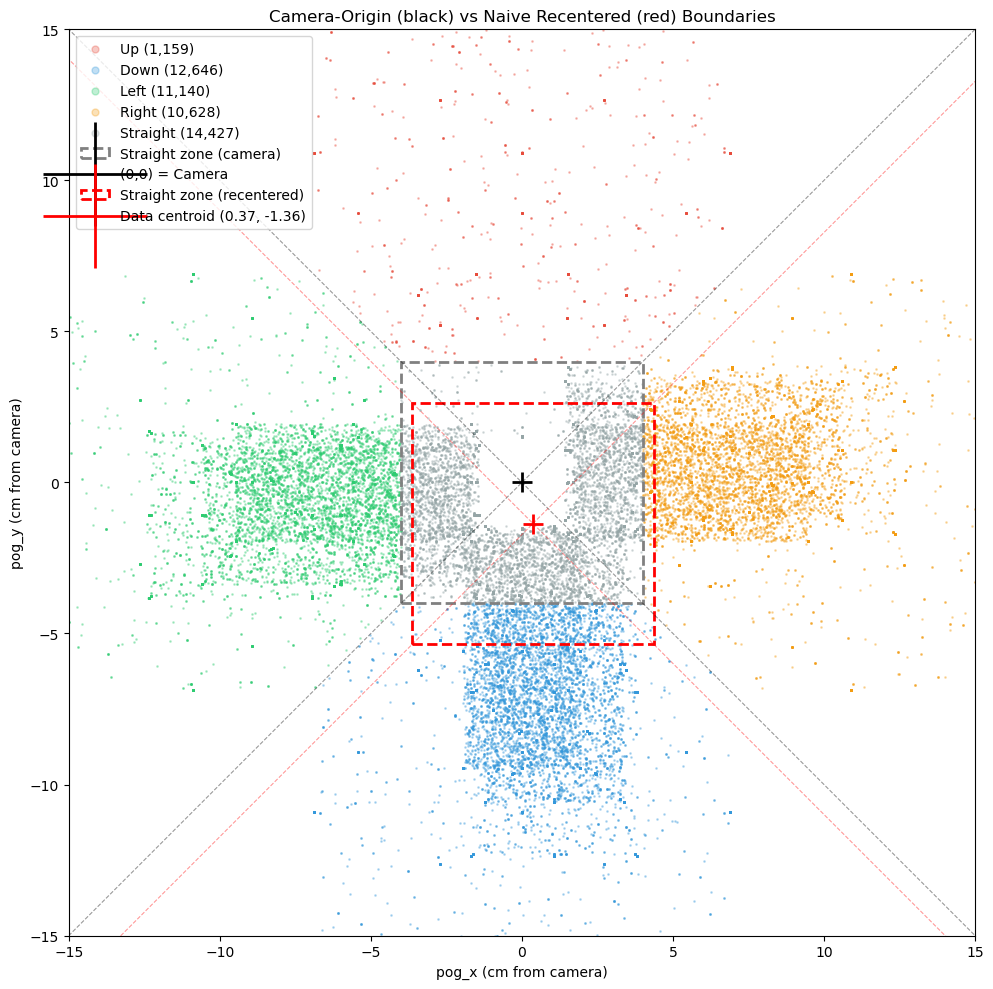

Data centroid: (0.37, -1.36)
Shift is mostly vertical — red boundaries pull the Up/Down split ~1.4 cm lower


In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

cx, cy = df['pog_x'].median(), df['pog_y'].median()
sample = df.sample(n=min(50_000, len(df)), random_state=42)

for label, color in label_colors.items():
    mask = sample['label'] == label
    if mask.sum() > 0:
        ax.scatter(sample.loc[mask, 'pog_x'], sample.loc[mask, 'pog_y'],
                   c=color, s=1, alpha=0.3, label=f"{label} ({mask.sum():,})")

# Camera-origin boundaries (current)
rect_cam = Rectangle((-4, -4), 8, 8, linewidth=2, edgecolor='gray',
                     facecolor='none', linestyle='--', label='Straight zone (camera)')
ax.add_patch(rect_cam)
lim = 20
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, alpha=0.4)
ax.plot([-lim, lim], [lim, -lim], 'k--', linewidth=0.8, alpha=0.4)
ax.plot(0, 0, 'k+', markersize=15, markeredgewidth=2, label='(0,0) = Camera')

# Naive recentered boundaries
rect_naive = Rectangle((cx - 4, cy - 4), 8, 8, linewidth=2, edgecolor='red',
                        facecolor='none', linestyle='--', label='Straight zone (recentered)')
ax.add_patch(rect_naive)
ax.plot([cx - lim, cx + lim], [cy - lim, cy + lim], 'r--', linewidth=0.8, alpha=0.4)
ax.plot([cx - lim, cx + lim], [cy + lim, cy - lim], 'r--', linewidth=0.8, alpha=0.4)
ax.plot(cx, cy, 'r+', markersize=15, markeredgewidth=2,
        label=f'Data centroid ({cx:.2f}, {cy:.2f})')

ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_xlabel('pog_x (cm from camera)')
ax.set_ylabel('pog_y (cm from camera)')
ax.set_title('Camera-Origin (black) vs Naive Recentered (red) Boundaries')
ax.set_aspect('equal')
ax.legend(markerscale=5, loc='upper left')
plt.tight_layout()
plt.show()

print(f"Data centroid: ({cx:.2f}, {cy:.2f})")
print(f"Shift is mostly vertical — red boundaries pull the Up/Down split ~{abs(cy):.1f} cm lower")

---
## 4. Naive recentered boundaries only

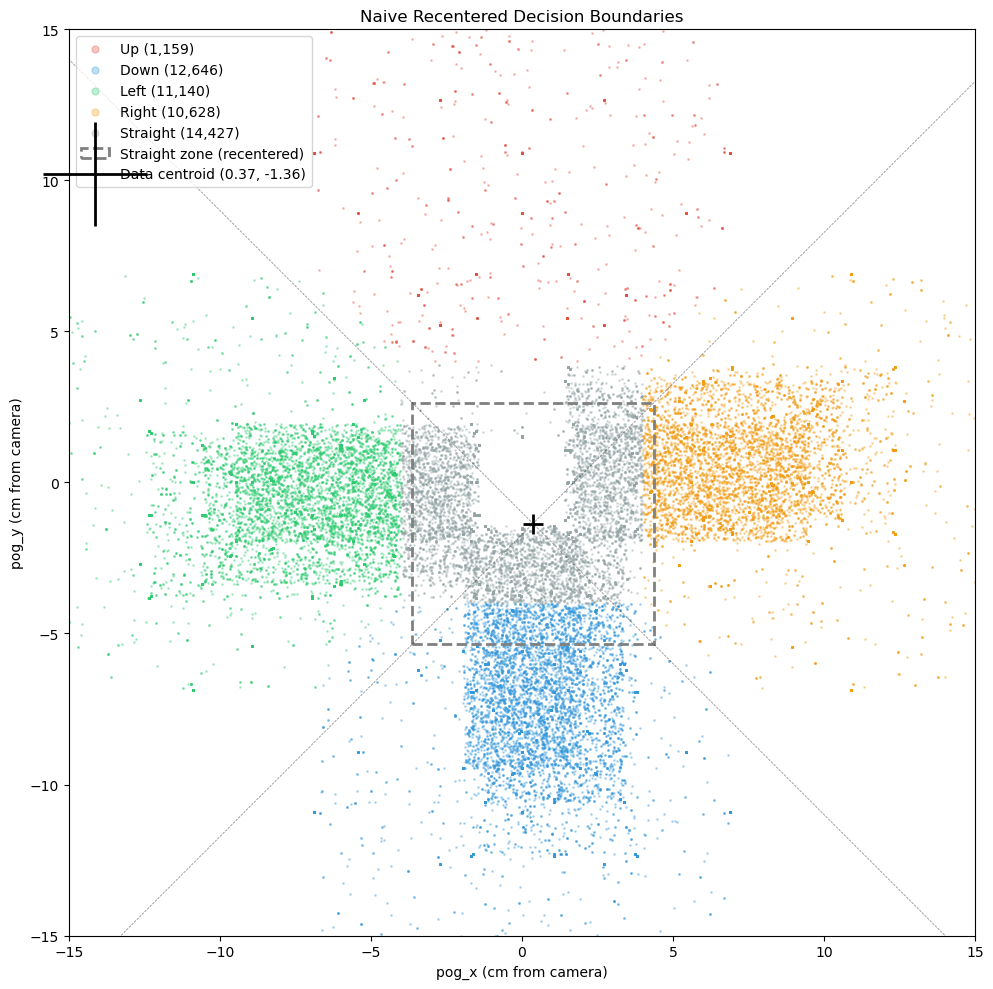

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))

sample = df.sample(n=min(50_000, len(df)), random_state=42)

for label, color in label_colors.items():
    mask = sample['label'] == label
    if mask.sum() > 0:
        ax.scatter(sample.loc[mask, 'pog_x'], sample.loc[mask, 'pog_y'],
                   c=color, s=1, alpha=0.3, label=f"{label} ({mask.sum():,})")

rect = Rectangle((cx - 4, cy - 4), 8, 8, linewidth=2, edgecolor='gray',
                 facecolor='none', linestyle='--', label='Straight zone (recentered)')
ax.add_patch(rect)

lim = 20
ax.plot([cx - lim, cx + lim], [cy - lim, cy + lim], 'k--', linewidth=0.5, alpha=0.5)
ax.plot([cx - lim, cx + lim], [cy + lim, cy - lim], 'k--', linewidth=0.5, alpha=0.5)
ax.plot(cx, cy, 'k+', markersize=15, markeredgewidth=2,
        label=f'Data centroid ({cx:.2f}, {cy:.2f})')

ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.set_xlabel('pog_x (cm from camera)')
ax.set_ylabel('pog_y (cm from camera)')
ax.set_title('Naive Recentered Decision Boundaries')
ax.set_aspect('equal')
ax.legend(markerscale=5, loc='upper left')
plt.tight_layout()
plt.show()

---
## 5. Side-by-side: 4-class labels before and after recentering

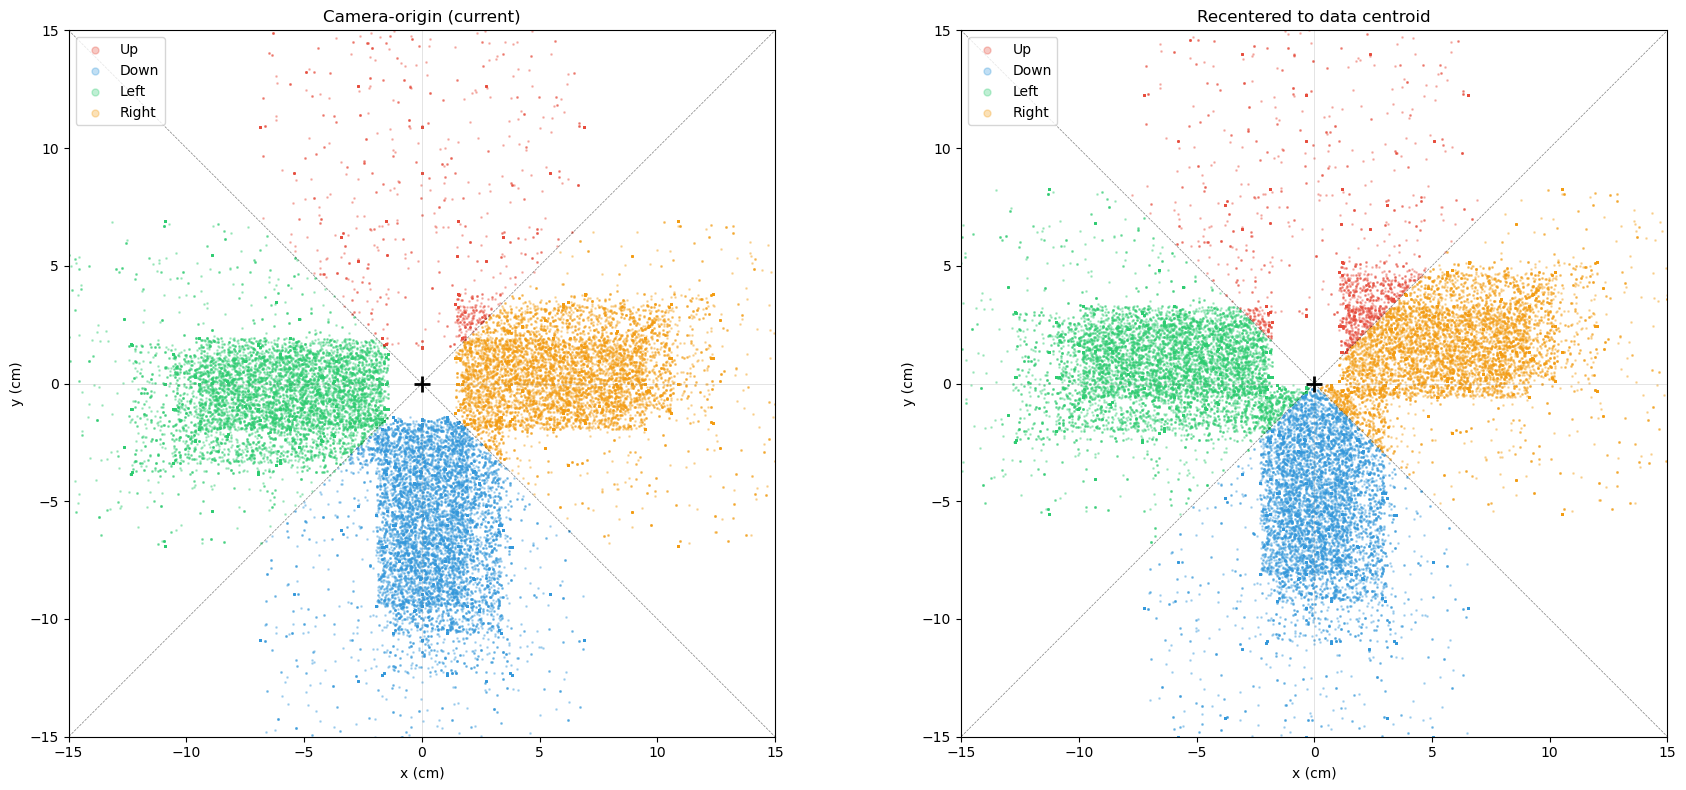

In [7]:
cx, cy = df['pog_x'].median(), df['pog_y'].median()

df['pog_x_shifted'] = df['pog_x'] - cx
df['pog_y_shifted'] = df['pog_y'] - cy

def label_4class(x, y):
    if abs(x) > abs(y):
        return 'Left' if x < 0 else 'Right'
    else:
        return 'Down' if y < 0 else 'Up'

df['label_4c_camera'] = df.apply(
    lambda r: label_4class(r['pog_x'], r['pog_y']), axis=1)
df['label_4c_shifted'] = df.apply(
    lambda r: label_4class(r['pog_x_shifted'], r['pog_y_shifted']), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sample = df.sample(n=min(50_000, len(df)), random_state=42)

for ax, x_col, y_col, lbl_col, title_str in [
    (axes[0], 'pog_x', 'pog_y', 'label_4c_camera', 'Camera-origin (current)'),
    (axes[1], 'pog_x_shifted', 'pog_y_shifted', 'label_4c_shifted', 'Recentered to data centroid')
]:
    for label, color in [('Up','#e74c3c'), ('Down','#3498db'),
                          ('Left','#2ecc71'), ('Right','#f39c12')]:
        mask = sample[lbl_col] == label
        if mask.sum() > 0:
            ax.scatter(sample.loc[mask, x_col], sample.loc[mask, y_col],
                       c=color, s=1, alpha=0.3, label=label)

    ax.plot([-20, 20], [-20, 20], 'k--', linewidth=0.5, alpha=0.5)
    ax.plot([-20, 20], [20, -20], 'k--', linewidth=0.5, alpha=0.5)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.3)
    ax.plot(0, 0, 'k+', markersize=12, markeredgewidth=2)

    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_aspect('equal')
    ax.set_xlabel('x (cm)')
    ax.set_ylabel('y (cm)')
    ax.set_title(title_str)
    ax.legend(markerscale=5, loc='upper left')

plt.tight_layout()
plt.show()

---
## 6. Quantify label impact

In [8]:
changed = df['label_4c_camera'] != df['label_4c_shifted']

print(f"Data centroid: ({cx:.2f}, {cy:.2f})")
print(f"Total samples: {len(df):,}")
print(f"Labels that would change: {changed.sum():,} ({changed.mean()*100:.1f}%)\n")

print("--- Camera-origin labels ---")
cam_counts = df['label_4c_camera'].value_counts()
for label in ['Up', 'Down', 'Left', 'Right']:
    ct = cam_counts.get(label, 0)
    print(f"  {label:6s}: {ct:>7,}  ({ct/len(df)*100:.1f}%)")

print("\n--- Centroid-recentered labels ---")
shift_counts = df['label_4c_shifted'].value_counts()
for label in ['Up', 'Down', 'Left', 'Right']:
    ct = shift_counts.get(label, 0)
    print(f"  {label:6s}: {ct:>7,}  ({ct/len(df)*100:.1f}%)")

print("\n--- Change per class ---")
for label in ['Up', 'Down', 'Left', 'Right']:
    ct_cam = cam_counts.get(label, 0)
    ct_cor = shift_counts.get(label, 0)
    print(f"  {label:6s}: {ct_cam:>7,} -> {ct_cor:>7,}  (Δ {ct_cor - ct_cam:+,})")

Data centroid: (0.37, -1.36)
Total samples: 849,131
Labels that would change: 72,483 (8.5%)

--- Camera-origin labels ---
  Up    :  38,640  (4.6%)
  Down  : 300,997  (35.4%)
  Left  : 257,091  (30.3%)
  Right : 252,403  (29.7%)

--- Centroid-recentered labels ---
  Up    :  69,632  (8.2%)
  Down  : 259,506  (30.6%)
  Left  : 274,657  (32.3%)
  Right : 245,336  (28.9%)

--- Change per class ---
  Up    :  38,640 ->  69,632  (Δ +30,992)
  Down  : 300,997 -> 259,506  (Δ -41,491)
  Left  : 257,091 -> 274,657  (Δ +17,566)
  Right : 252,403 -> 245,336  (Δ -7,067)


---
## 7. Why we can't do better than naive recentering

The correct correction requires per-frame device type and orientation, which are not in our pipeline. We explored whether per-subject coordinate spans could fingerprint device type, but this approach fails because **subjects rotated their devices during sessions**.

In [9]:
# ============================================================
# Evidence: subjects used multiple orientations
# ============================================================

per_subj = df.groupby('subject_id').agg(
    x_min=('pog_x', 'min'), x_max=('pog_x', 'max'),
    y_min=('pog_y', 'min'), y_max=('pog_y', 'max'),
    n=('pog_x', 'count')
).reset_index()
per_subj = per_subj[per_subj['n'] >= 100].copy()
per_subj['x_span'] = per_subj['x_max'] - per_subj['x_min']
per_subj['y_span'] = per_subj['y_max'] - per_subj['y_min']

# Key facts:
# - ALL 616 subjects have x_min < 0 (portrait frames)
# - 546/616 have x_max > 8 cm (must include landscape frames)
# - Multiple subjects span ±20.25 on both axes (40.5 cm total)
# - An iPhone 6s in portrait+landscape already spans 13+ cm on x
#   exceeding any single-orientation screen dimension

print(f"Subjects with >= 100 frames: {len(per_subj)}")
print(f"  ALL have x_min < 0:            {(per_subj['x_min'] < 0).sum()} / {len(per_subj)}")
print(f"  Subjects with x_max > 8 cm:    {(per_subj['x_max'] > 8).sum()} / {len(per_subj)}")
print(f"  Subjects spanning full ±20 cm:  "
      f"{((per_subj['x_span'] > 40) & (per_subj['y_span'] > 40)).sum()} / {len(per_subj)}")

print(f"\nMedian x_span: {per_subj['x_span'].median():.2f} cm")
print(f"Median y_span: {per_subj['y_span'].median():.2f} cm")

print(f"\nFor reference — an iPhone 6s portrait+landscape combined span is ~13 cm on x.")
print(f"An iPad Air across all 4 orientations spans ~41 cm on both axes.")
print(f"Without per-frame orientation data, we cannot separate these.")

Subjects with >= 100 frames: 616
  ALL have x_min < 0:            616 / 616
  Subjects with x_max > 8 cm:    546 / 616
  Subjects spanning full ±20 cm:  33 / 616

Median x_span: 18.93 cm
Median y_span: 11.77 cm

For reference — an iPhone 6s portrait+landscape combined span is ~13 cm on x.
An iPad Air across all 4 orientations spans ~41 cm on both axes.
Without per-frame orientation data, we cannot separate these.


---
## 8. Camera-to-screen-center offsets per device

From `apple_device_data.csv` in the GazeCapture repo. The x offset is < 1.1 cm for every device (Left/Right barely affected). The y offset is where the distortion lives, and it varies per device and orientation — which we don't have.

In [ ]:
devices = pd.read_csv(DEVICE_CSV_PATH)

# Screen center in camera coords (portrait, from screen2cam.m orientation 1)
devices['portrait_center_x'] = (
    devices['DeviceScreenWidthMm'] / 2 - devices['DeviceCameraToScreenXMm']
) / 10
devices['portrait_center_y'] = (
    -devices['DeviceCameraToScreenYMm'] - devices['DeviceScreenHeightMm'] / 2
) / 10

print("Screen center in camera coordinates (portrait mode):")
print(f"{'Device':<20s} {'x_offset':>10s} {'y_offset':>10s}")
print("-" * 42)
for _, row in devices.iterrows():
    print(f"{row['DeviceName']:<20s} "
          f"{row['portrait_center_x']:>+10.2f} "
          f"{row['portrait_center_y']:>+10.2f}")

print(f"\nKey points:")
print(f"  x offset < 1.1 cm for ALL devices -> Left/Right barely affected")
print(f"  y offset: -5 to -7 cm (phones), -9 to -14 cm (iPads) in portrait")
print(f"  In landscape: y offset is ~0 (camera on short edge)")
print(f"  The true correction is per-frame, not per-subject or global")

Screen center in camera coordinates (portrait mode):
Device                 x_offset   y_offset
------------------------------------------
iPhone 6s Plus            +1.06      -6.94
iPhone 6s                 +1.06      -6.01
iPhone 6 Plus             +1.06      -6.94
iPhone 6                  +1.06      -6.01
iPhone 5s                 +0.00      -5.58
iPhone 5c                 +0.00      -5.58
iPhone 5                  +0.00      -5.58
iPhone 4s                 +1.00      -4.72
iPad Mini                 -0.01      -8.93
iPad Air 2                -0.00     -10.89
iPad Air                  +0.01     -10.89
iPad 4                    +0.00     -10.96
iPad 3                    +0.00     -10.96
iPad 2                    +0.00     -10.96
iPad Pro                  -0.00     -14.18

Key points:
  x offset < 1.1 cm for ALL devices -> Left/Right barely affected
  y offset: -5 to -7 cm (phones), -9 to -14 cm (iPads) in portrait
  In landscape: y offset is ~0 (camera on short edge)
  The true corre

---
## 9. Takeaways

### What we confirmed

1. **The origin is at the camera**, not screen center. Documented by MIT, confirmed empirically by the negative pog_y bias.

2. **The x-axis is essentially unaffected.** The camera sits within ~1 cm of horizontal center on every Apple device. Left/Right labels are minimally distorted.

3. **The y-axis offset is device- and orientation-dependent.** Portrait phones: ~6 cm. Portrait iPads: ~11-14 cm. Landscape anything: ~0 cm. Subjects rotated devices during sessions, mixing orientations within a single subject's data.

4. **A naive global recentering shifts ~8.5% of 4-class labels**, mostly moving Down→Up. Up roughly doubles from ~4.6% to ~8.2%.

5. **We cannot do a proper per-frame correction.** Device type and orientation metadata (`info.json`, `screen.json`) were stripped before our pipeline. The original MIT dataset download is broken. Per-subject coordinate spans cannot fingerprint device type because subjects used multiple orientations.

### Impact on M5c

The model learns from **images**, not coordinates. The labels define a consistent mapping from visual appearance to direction class. Because the same labeling rule was applied to every frame, the model learns a coherent decision function. The camera-origin bias shifts the Up/Down boundary relative to screen center, but the visual mapping remains internally consistent.

### Recommendation

Document as a known limitation. The ~8.5% label distortion is real but bounded, concentrated on the Up/Down boundary, and does not invalidate the image-based model.